In [1]:
import pandas as pd
from datasets import Dataset
from transformers import GPT2Tokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from transformers.utils.notebook import NotebookProgressCallback
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay
import torch
import matplotlib.pyplot as plt

# GPU check
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU not available.")

# Ensure reproducibility across runs
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
torch.backends.cudnn.deterministic = True

/usr/local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GPU: NVIDIA GeForce RTX 4080


In [2]:
df = pd.read_csv('../datasets/smishing.csv')
df = df[["LABEL", "TEXT"]]
df["label"] = df["LABEL"].apply(lambda x: 0 if x == "ham" else 1)
dataset = Dataset.from_pandas(df)

In [3]:
tokenizer = GPT2Tokenizer.from_pretrained("distilgpt2")
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForSequenceClassification.from_pretrained("distilgpt2", num_labels=2)
model.config.pad_token_id = model.config.eos_token_id

You passed `num_labels=2` which is incompatible to the `id2label` map of length `1`.


Loading weights:   0%|                                                                                                   | 0/76 [00:00<?, ?it/s]

Loading weights: 100%|████████████████████████████████████████████████████████████████████████████████████████| 76/76 [00:00<00:00, 2175.44it/s]


GPT2ForSequenceClassification LOAD REPORT from: distilgpt2
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [4]:
def tokenize(batch):
    return tokenizer(batch["TEXT"], padding="max_length", truncation=True)

dataset = dataset.map(tokenize, batched=True)
split = dataset.train_test_split(test_size=0.2, seed=42)
test_dataset = split["test"]

Map:   0%|                                                                                                      | 0/5971 [00:00<?, ? examples/s]

Map:  17%|██████████████▉                                                                          | 1000/5971 [00:00<00:00, 5008.96 examples/s]

Map:  33%|█████████████████████████████▊                                                           | 2000/5971 [00:00<00:00, 6652.45 examples/s]

Map:  67%|███████████████████████████████████████████████████████████▌                             | 4000/5971 [00:00<00:00, 9066.37 examples/s]

Map: 100%|████████████████████████████████████████████████████████████████████████████████████████| 5971/5971 [00:00<00:00, 10242.70 examples/s]

Map: 100%|█████████████████████████████████████████████████████████████████████████████████████████| 5971/5971 [00:00<00:00, 9058.56 examples/s]

In [5]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="binary")
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}

training_args = TrainingArguments(
    output_dir=".checkpoints/gpt2-sms-baseline",
    per_device_eval_batch_size=16,
    fp16=True,
    save_strategy="no",
)

trainer = Trainer(
    model=model,
    args=training_args,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

# evaluate() without prior train() requires this
trainer.remove_callback(NotebookProgressCallback)

metrics = trainer.evaluate()
print("\nBaseline metrics (no fine-tuning):")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")


Baseline metrics (no fine-tuning):
eval_loss: 1.5049
eval_model_preparation_time: 0.0005
eval_accuracy: 0.8050
eval_f1: 0.0000
eval_precision: 0.0000
eval_recall: 0.0000
eval_runtime: 7.4514
eval_samples_per_second: 160.3740
eval_steps_per_second: 10.0650
epoch: 0.0000


/usr/local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


/usr/local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


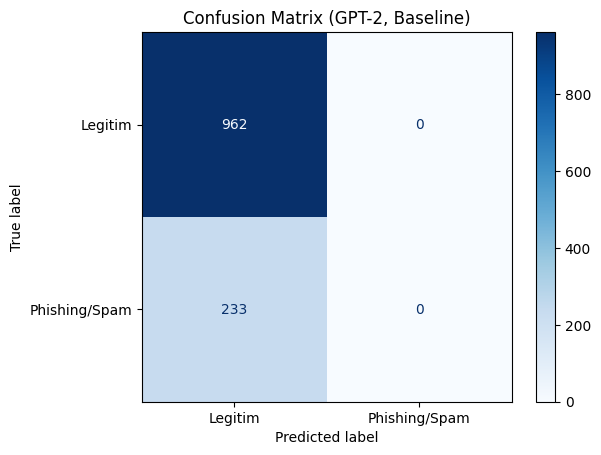

In [6]:
predictions = trainer.predict(test_dataset)
y_true = predictions.label_ids
y_pred = predictions.predictions.argmax(-1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legitim", "Phishing/Spam"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (GPT-2, Baseline)")
plt.show()